# 1. Importação de Bibliotecas e Configurações

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurações de visualização
%matplotlib inline
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# 2. Carga dos Dados

In [23]:
# O caminho relativo partindo da pasta 'notebooks'
csv_path = '../data/raw/games.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Dataset carregado! Total de linhas: {df.shape[0]}")
else:
    print("Erro: Arquivo não encontrado. Verifique o caminho!")

# Visualização das primeiras linhas (limpando colunas irrelevantes para o Perceptron)
cols_view = ['white_rating', 'black_rating', 'winner', 'victory_status', 'turns']
display(df[cols_view].head())

Dataset carregado! Total de linhas: 20058


,white_rating,black_rating,winner,victory_status,turns
0,1500,1191,white,outoftime,13
1,1322,1261,black,resign,16
2,1496,1500,white,mate,61
3,1439,1454,white,mate,61
4,1523,1469,white,mate,95


# 3. Limpeza e Engenharia de Dados

In [24]:
# 1. Removendo empates (O Perceptron clássico é um classificador binário)
df_filtered = df[df['winner'] != 'draw'].copy()

# 2. Criando o Target (Y): 1 para White, 0 para Black
df_filtered['target'] = df_filtered['winner'].apply(lambda x: 1 if x == 'white' else 0)

# 3. Selecionando as Features (X1 e X2)
# Vamos usar os Ratings dos jogadores como entrada
df_final = df_filtered[['white_rating', 'black_rating', 'target']].copy()

print(f"Dados filtrados (sem empates): {df_final.shape[0]} partidas.")
display(df_final.head())

Dados filtrados (sem empates): 19108 partidas.


,white_rating,black_rating,target
0,1500,1191,1
1,1322,1261,0
2,1496,1500,1
3,1439,1454,1
4,1523,1469,1


# 4. Análise Visual

## 4.1 Distribuição de vitórias

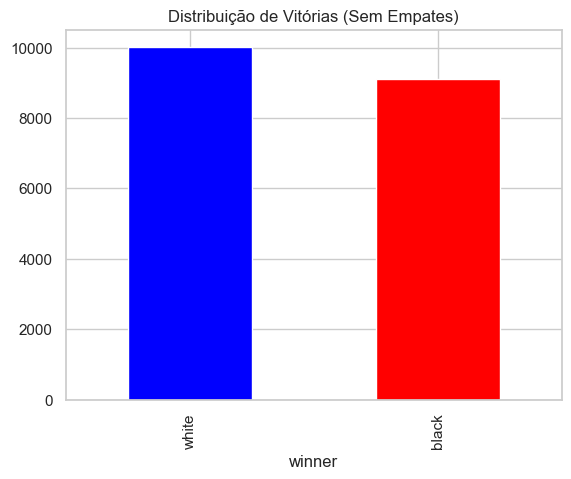

In [27]:
# Gráfico 1: Distribuição de vitórias
df_filtered['winner'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Distribuição de Vitórias (Sem Empates)')
plt.show()


## 4.2 Fronteira de Decisão

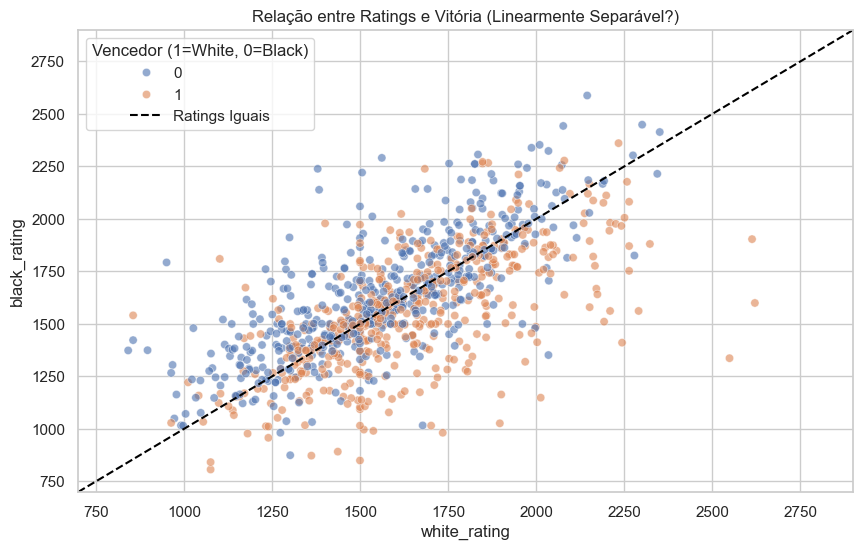

In [28]:
plt.figure(figsize=(10, 6))
# Usamos um sample de 1000 para não travar o VS Code
sns.scatterplot(data=df_final.sample(1000), x='white_rating', y='black_rating', hue='target', alpha=0.6)

# Linha de igualdade (onde o Perceptron teoricamente traçaria sua fronteira inicial)
plt.axline((800, 800), (2800, 2800), color='black', linestyle='--', label='Ratings Iguais')

plt.title('Relação entre Ratings e Vitória (Linearmente Separável?)')
plt.legend(title='Vencedor (1=White, 0=Black)')
plt.show()

# 5. Definição das Entradas do Perceptron

In [29]:
# Exemplo de como os dados serão passados para o neurônio
X = df_final[['white_rating', 'black_rating']].values.tolist()
y = df_final['target'].values.tolist()

print("Exemplo de entrada para o Perceptron (x1, x2):", X[0])
print("Exemplo de rótulo esperado (target):", y[0])

Exemplo de entrada para o Perceptron (x1, x2): [1500, 1191]
Exemplo de rótulo esperado (target): 1
